# Georgia ECG Dataset — Preprocessing

Loads raw `.mat`/`.hea` files, maps SNOMED-CT codes → {MI, STTC, CD, HYP}, resamples 500 Hz → 100 Hz, saves `(N, 12, 1000)` signal array and `(N, 4)` label matrix as pickles.

In [1]:
import numpy as np
import pickle
import pathlib
import scipy.signal
import scipy.io

DATA_DIR  = pathlib.Path("../GeorgiaECGDataset/Georgia")
OUT_DIR   = pathlib.Path("../GeorgiaECG")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FS_ORIG   = 500   # original sampling rate
FS_TARGET = 100   # target sampling rate
N_SAMPLES = 1000  # = FS_TARGET * 10 s
GAIN_FACTOR = 4880.0  # ADC units per mV (from headers)

## SNOMED-CT → Class Mapping

In [2]:
# SNOMED-CT code → class index mapping
# 0=MI, 1=STTC, 2=CD, 3=HYP
SNOMED_MAP = {
    # MI
    164865005: 0, 413444003: 0, 425419005: 0, 426434006: 0,
    54329005:  0, 57054005:  0, 164931005: 0,
    # STTC
    164934002: 1, 164930006: 1, 59931005:  1, 698252002: 1,
    111975006: 1, 429622005: 1, 55930002:  1,
    # CD
    164889003: 2, 59118001:  2, 270492004: 2, 713426002: 2,
    6374002:   2, 164909002: 2, 445118002: 2, 164890007: 2,
    445211001: 2, 713427006: 2, 195042002: 2, 233917008: 2,
    426995002: 2, 425623009: 2, 164917005: 2, 17338001:  2,
    428417006: 2, 251120003: 2, 27885002:  2,
    # HYP
    164873001: 3, 428750005: 3, 251146004: 3, 67741000119109: 3,
    89792004:   3, 47665007:  3, 164884008: 3,
}
CLASS_NAMES = ["MI", "STTC", "CD", "HYP"]
print(f"Mapped {len(SNOMED_MAP)} SNOMED codes → {len(CLASS_NAMES)} classes")


Mapped 40 SNOMED codes → 4 classes


## Load All Recordings

In [3]:
hea_files = sorted(DATA_DIR.glob("*.hea"))
print(f"Found {len(hea_files)} recordings in {DATA_DIR}")


Found 10344 recordings in ../GeorgiaECGDataset/Georgia


In [4]:
def parse_dx(hea_path):
    """Return list of int SNOMED codes from #Dx line of .hea file."""
    codes = []
    with open(hea_path) as f:
        for line in f:
            if line.startswith("#Dx:"):
                raw = line.strip().split(":", 1)[1].strip()
                for c in raw.split(","):
                    c = c.strip()
                    if c:
                        try:
                            codes.append(int(c))
                        except ValueError:
                            pass
    return codes


def load_record(hea_path):
    """Load 12-lead signal via scipy.io (avoids wfdb format-16+offset issue).
    Returns float32 array shape (12, N_SAMPLES) in mV."""
    mat_path = hea_path.with_suffix(".mat")
    mat = scipy.io.loadmat(str(mat_path))
    sig = mat["val"].astype(np.float32)  # (12, N_orig)
    sig = sig / GAIN_FACTOR              # ADC → mV
    # Resample from FS_ORIG to FS_TARGET
    n_target = int(sig.shape[1] * FS_TARGET / FS_ORIG)
    sig_rs = scipy.signal.resample(sig, n_target, axis=1)
    # Crop or pad to exactly N_SAMPLES
    if sig_rs.shape[1] >= N_SAMPLES:
        sig_rs = sig_rs[:, :N_SAMPLES]
    else:
        pad = N_SAMPLES - sig_rs.shape[1]
        sig_rs = np.pad(sig_rs, ((0, 0), (0, pad)))
    return sig_rs.astype(np.float32)

In [5]:
X_list, y_list = [], []
skipped = 0

for hea_path in hea_files:
    try:
        sig = load_record(hea_path)
    except Exception as e:
        print(f"  SKIP {hea_path.name}: {e}")
        skipped += 1
        continue

    codes  = parse_dx(hea_path)
    label  = np.zeros(4, dtype=np.float32)
    for c in codes:
        if c in SNOMED_MAP:
            label[SNOMED_MAP[c]] = 1.0

    X_list.append(sig)
    y_list.append(label)

X_all = np.stack(X_list, axis=0)  # (N, 12, 1000)
y_all = np.stack(y_list, axis=0)  # (N, 4)
print(f"Loaded {len(X_list)} recordings, skipped {skipped}")
print(f"X shape: {X_all.shape}, y shape: {y_all.shape}")


Loaded 10344 recordings, skipped 0
X shape: (10344, 12, 1000), y shape: (10344, 4)


## Dataset Statistics

In [6]:
norm_mask = y_all.sum(axis=1) == 0
print("Class prevalence:")
for i, name in enumerate(CLASS_NAMES):
    n = int(y_all[:, i].sum())
    print(f"  {name}: {n} ({100*n/len(y_all):.1f}%)")
print(f"  NORM (no label): {norm_mask.sum()} ({100*norm_mask.mean():.1f}%)")
print(f"  Multi-label (2+ classes): {int((y_all.sum(axis=1) >= 2).sum())} ({100*(y_all.sum(axis=1)>=2).mean():.1f}%)")


Class prevalence:
  MI: 842 (8.1%)
  STTC: 3750 (36.3%)
  CD: 3764 (36.4%)
  HYP: 3918 (37.9%)
  NORM (no label): 2999 (29.0%)
  Multi-label (2+ classes): 3705 (35.8%)


## Save Pickles

In [7]:
with open(OUT_DIR / "X_georgia.pickle", "wb") as f:
    pickle.dump(X_all, f)
with open(OUT_DIR / "y_georgia.pickle", "wb") as f:
    pickle.dump(y_all, f)

print(f"Saved to {OUT_DIR}/")
print(f"  X_georgia.pickle: {X_all.shape}  {X_all.dtype}")
print(f"  y_georgia.pickle: {y_all.shape}  {y_all.dtype}")


Saved to ../GeorgiaECG/
  X_georgia.pickle: (10344, 12, 1000)  float32
  y_georgia.pickle: (10344, 4)  float32


## Quick Sanity Check

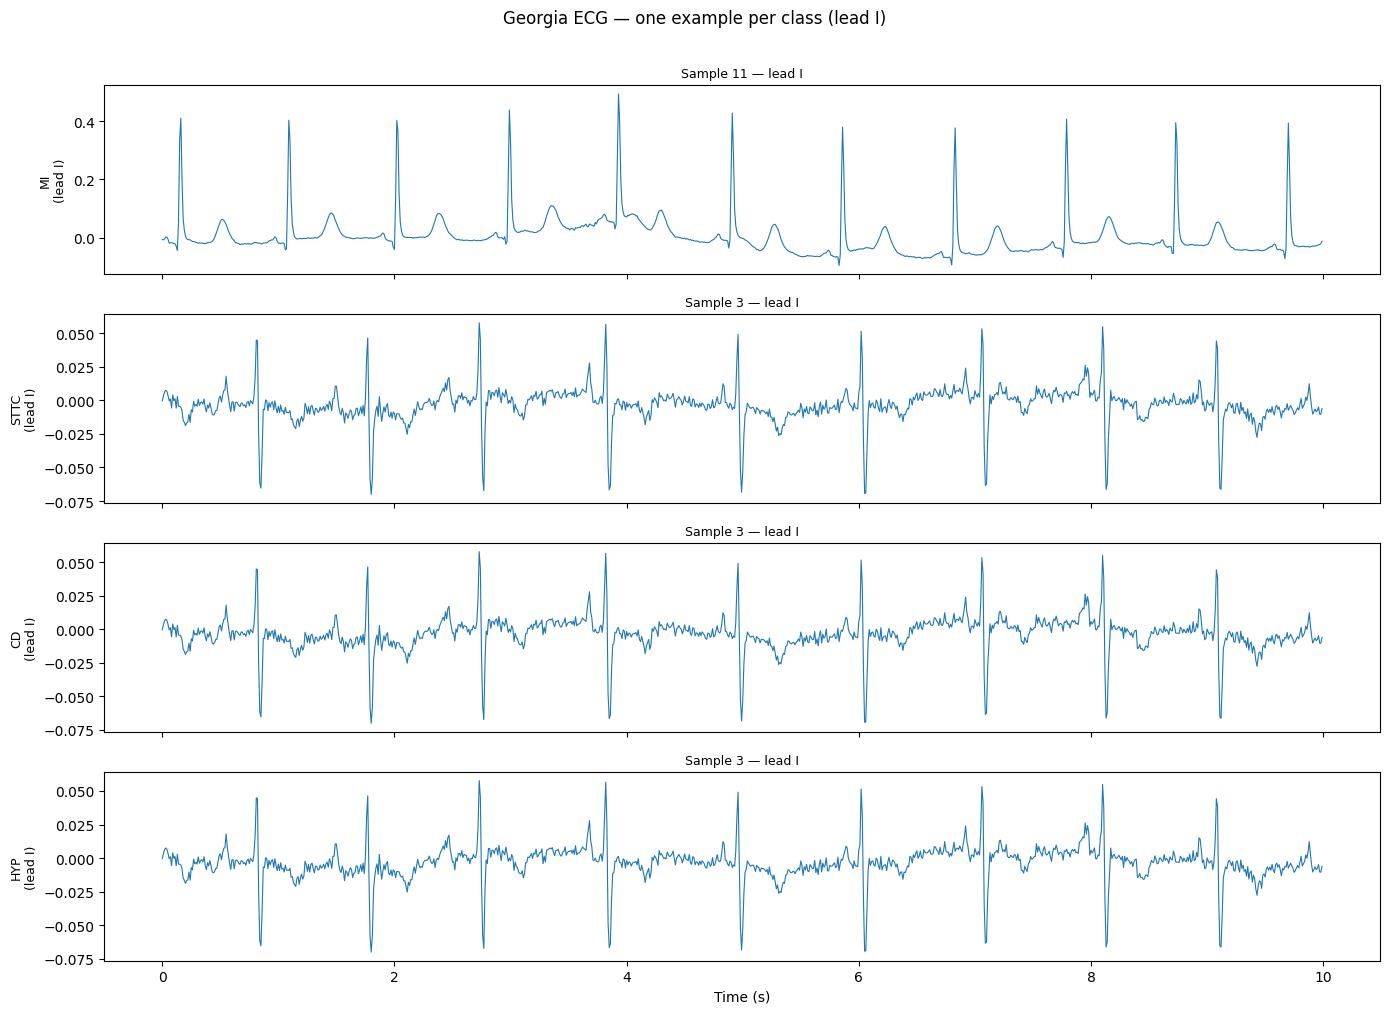

Done.


In [8]:
import matplotlib.pyplot as plt

# Plot one sample per class
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, (ax, name) in enumerate(zip(axes, CLASS_NAMES)):
    idx = np.where(y_all[:, i] == 1)[0][0]
    t = np.arange(N_SAMPLES) / FS_TARGET
    ax.plot(t, X_all[idx, 0], lw=0.8)
    ax.set_ylabel(f"{name}\n(lead I)", fontsize=9)
    ax.set_title(f"Sample {idx} — lead I", fontsize=9)
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Georgia ECG — one example per class (lead I)", y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / "georgia_sample_ecgs.png", dpi=100, bbox_inches="tight")
plt.show()
print("Done.")
